Inspecionando valores nulos:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Primeiras linhas do dataset:
   Diabetes_binary  HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  \
0                0       1         0          1   26       0       0   
1                0       1         1          1   26       1       1   
2                0       0         0          1   26       0       0   
3                0       1         1          1   28       1       0

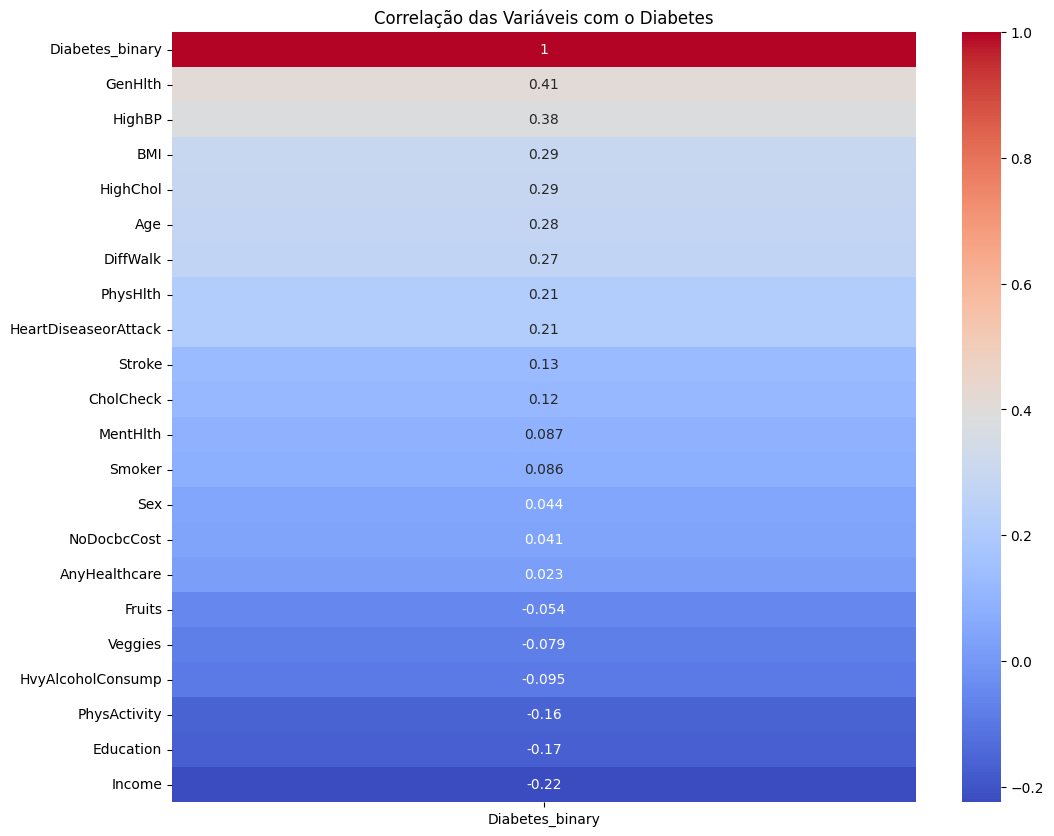


--- Importância das Variáveis ---
BMI                     0.170330
Age                     0.126867
GenHlth                 0.101952
Income                  0.084287
HighBP                  0.077724
PhysHlth                0.068045
Education               0.057108
MentHlth                0.051976
HighChol                0.040477
Smoker                  0.028869
Fruits                  0.028649
Sex                     0.026949
DiffWalk                0.026396
PhysActivity            0.023660
Veggies                 0.022097
HeartDiseaseorAttack    0.019480
NoDocbcCost             0.011961
Stroke                  0.009942
HvyAlcoholConsump       0.009808
AnyHealthcare           0.007729
CholCheck               0.005691
dtype: float64


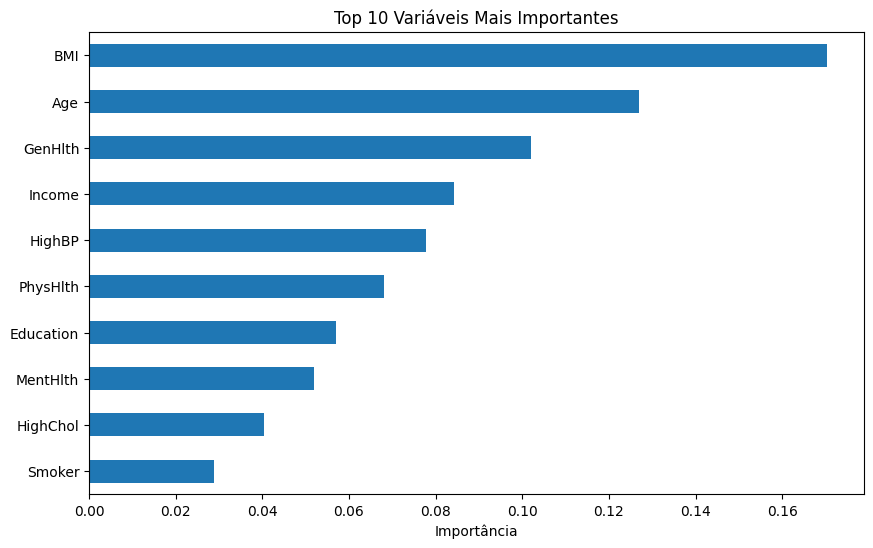


Arquivo 'feature_importance.csv' gerado com sucesso!

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.76      0.70      0.73     10601
           1       0.72      0.78      0.75     10607

    accuracy                           0.74     21208
   macro avg       0.74      0.74      0.74     21208
weighted avg       0.74      0.74      0.74     21208


--- Acurácia Final ---
73.83%

--- Matriz de Confusão ---
[[7429 3172]
 [2378 8229]]


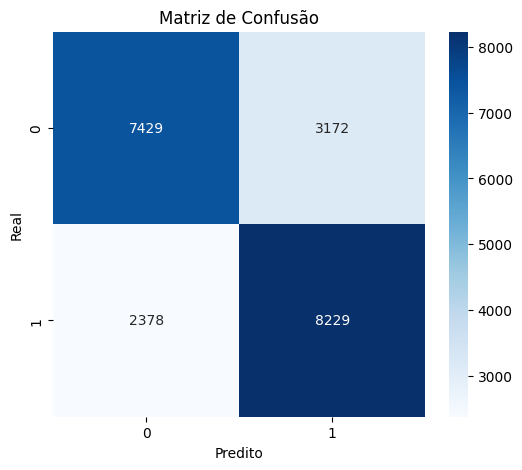


Arquivo 'diabetes_limpo_para_BI.csv' gerado com sucesso!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# 1. CARREGAMENTO DOS DADOS

df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')


# 2. LIMPEZA E EXPLORAÇÃO INICIAL

print("Inspecionando valores nulos:")
print(df.isnull().sum())

# Transformando tipos para inteiro
df = df.astype(int)

print("\nPrimeiras linhas do dataset:")
print(df.head())

print("\nInformações gerais:")
print(df.info())

print("\nEstatísticas descritivas:")
print(df.describe())


# 3. ANÁLISE PARA O BI (CORRELAÇÃO)

plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr()[['Diabetes_binary']].sort_values(by='Diabetes_binary', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlação das Variáveis com o Diabetes")
plt.show()


# 4. PREPARAÇÃO PARA O ANALYTICS (MACHINE LEARNING)

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# 5. CONSTRUÇÃO DO MODELO PREDITIVO

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)


# 6. IMPORTÂNCIA DAS VARIÁVEIS

importances = modelo.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print("\n--- Importância das Variáveis ---")
print(feat_imp)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.gca().invert_yaxis()  # deixa a mais importante em cima
plt.show()

# Exportando importância das variáveis para BI
feat_imp_df = feat_imp.reset_index()
feat_imp_df.columns = ['Variavel', 'Importancia']
feat_imp_df.to_csv('feature_importance.csv', index=False)
print("\nArquivo 'feature_importance.csv' gerado com sucesso!")


# 7. AVALIAÇÃO DO MODELO

predicoes = modelo.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, predicoes))

print("\n--- Acurácia Final ---")
print(f"{accuracy_score(y_test, predicoes) * 100:.2f}%")


# 8. MATRIZ DE CONFUSÃO

matriz = confusion_matrix(y_test, predicoes)

print("\n--- Matriz de Confusão ---")
print(matriz)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


# 9. EXPORTAÇÃO PARA O BI

df.to_csv('diabetes_limpo_para_BI.csv', index=False)
print("\nArquivo 'diabetes_limpo_para_BI.csv' gerado com sucesso!")